# IFA2 Interconnector — Descriptive Statistics (Methodology 1)

**Methodology:** Abadie & Chamorro (2021), *Energy* 233, 121177  
**Project flow:** Interconnectors_Equity_focus (Steps 1–2)  

| Data | Source | Unit |
|---|---|---|
| GB hourly day-ahead prices | Bloomberg N2EXEH01-24 | GBP/MWh |
| FR hourly day-ahead prices | Bloomberg PWNXFR01-24 | EUR/MWh |
| EURGBP daily FX rate | Bloomberg EURGBP Currency | GBP per 1 EUR |

**FX convention:** `EUR/GBP` column ≈ 0.89 → 1 EUR = 0.89 GBP  
→ `FR_price_GBP = FR_price_EUR × fx_eur_gbp`

**Stops before:** OLS deterministic component, OU/jump estimation, Monte Carlo.

---
## 0. Imports & Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from statsmodels.tsa.stattools import adfuller

EXCEL_PATH  = Path("/Users/aadesh/Documents/IC/Cleaned_GBFR.xlsx")
OUTPUT_DIR  = Path("/Users/aadesh/Documents/IC/M1")
OUTPUT_DIR.mkdir(exist_ok=True)
GB_SHEET    = "GB_FINAL"
FR_SHEET    = "FR_FINAL"
FX_SHEET    = "GBP-EUR"
SHORT_GAP_H = 4   # ≤ 4 consecutive missing hours → interpolate; longer → drop

pd.set_option("display.float_format", "{:.4f}".format)
pd.set_option("display.max_columns", 10)

---
## 1. Load

In [2]:
def load_from_excel(filepath: Path):
    """
    Load GB_FINAL, FR_FINAL, and GBP-EUR sheets.
    Returns three raw DataFrames in wide day × H01..H24 format.
    """
    filepath = Path(filepath)
    if not filepath.exists():
        raise FileNotFoundError(f"Excel file not found: {filepath}")

    xl       = pd.ExcelFile(filepath)
    gb_wide  = xl.parse(GB_SHEET)
    fr_wide  = xl.parse(FR_SHEET)
    fx_daily = xl.parse(FX_SHEET)

    print(f"Loaded '{filepath.name}'")
    print(f"  {GB_SHEET}: {gb_wide.shape[0]} days × {gb_wide.shape[1]-1} hours")
    print(f"  {FR_SHEET}: {fr_wide.shape[0]} days × {fr_wide.shape[1]-1} hours")
    print(f"  {FX_SHEET}: {fx_daily.shape[0]} daily FX observations")
    return gb_wide, fr_wide, fx_daily

gb_wide, fr_wide, fx_daily = load_from_excel(EXCEL_PATH)

Loaded 'Cleaned_GBFR.xlsx'
  GB_FINAL: 1540 days × 24 hours
  FR_FINAL: 1888 days × 24 hours
  GBP-EUR: 1343 daily FX observations


---
## 2. Clean Panel

In [3]:
def _wide_to_hourly(wide_df: pd.DataFrame, value_col: str) -> pd.Series:
    """
    Melt wide day × H01..H24 DataFrame into a long hourly Series.
    Convention: H01 = 00:00-01:00 → timestamp 00:00, ..., H24 → 23:00.
    """
    df = wide_df.rename(columns={"Unnamed: 0": "date"}).copy()
    df["date"] = pd.to_datetime(df["date"])

    hour_cols = sorted(
        [c for c in df.columns if c.startswith("H") and c[1:].isdigit()],
        key=lambda x: int(x[1:]),
    )
    melted = df.melt(id_vars="date", value_vars=hour_cols,
                     var_name="hour_col", value_name=value_col)
    melted["offset"]    = melted["hour_col"].str[1:].astype(int) - 1
    melted["timestamp"] = melted["date"] + pd.to_timedelta(melted["offset"], unit="h")
    return melted.set_index("timestamp")[value_col].sort_index().astype(float)


def clean_panel(gb_wide, fr_wide, fx_daily) -> pd.DataFrame:
    """
    Build clean hourly panel: gb_price_gbp, fr_price_eur, fx_eur_gbp.

    Cleaning rules:
      1. Duplicate timestamps        → keep last.
      2. ≤ SHORT_GAP_H missing hours → linear interpolation.
      3. > SHORT_GAP_H missing hours → drop (not imputed).

    Panel restricted to the period where BOTH GB and FR data exist.
    FX forward-filled over weekends/holidays; broadcast daily → hourly.
    """
    gb_s = _wide_to_hourly(gb_wide, "gb_price_gbp")
    fr_s = _wide_to_hourly(fr_wide, "fr_price_eur")

    # FX: parse → daily index → forward-fill non-trading days
    fx = fx_daily.copy()
    fx.columns = ["date", "fx_eur_gbp"]
    fx["date"] = pd.to_datetime(fx["date"])
    fx = fx.dropna(subset=["fx_eur_gbp"]).set_index("date").sort_index()
    fx = fx.reindex(pd.date_range(fx.index.min(), fx.index.max(), freq="D")).ffill()

    panel = pd.concat([gb_s, fr_s], axis=1, sort=True)

    # Rule 1: duplicates
    n_dups = panel.index.duplicated().sum()
    if n_dups:
        panel = panel[~panel.index.duplicated(keep="last")]
        print(f"  [clean] Removed {n_dups} duplicate timestamps (kept last).")

    # Restrict to overlap period
    overlap_start = max(panel["gb_price_gbp"].first_valid_index(),
                        panel["fr_price_eur"].first_valid_index())
    overlap_end   = min(panel["gb_price_gbp"].last_valid_index(),
                        panel["fr_price_eur"].last_valid_index())
    panel = panel.loc[overlap_start:overlap_end]

    # Reindex to full hourly grid
    panel = panel.reindex(pd.date_range(panel.index.min(), panel.index.max(), freq="h"))

    # Rule 2: short gaps → interpolate
    panel = panel.interpolate(method="linear", limit=SHORT_GAP_H)

    # Rule 3: long gaps → drop
    n_dropped = panel.isnull().any(axis=1).sum()
    if n_dropped:
        panel = panel.dropna()
        print(f"  [clean] Dropped {n_dropped} hours with gaps > {SHORT_GAP_H} h.")

    # Attach FX: normalise hourly timestamps to dates → map daily FX
    panel["fx_eur_gbp"] = panel.index.normalize().map(fx["fx_eur_gbp"])
    panel["fx_eur_gbp"] = panel["fx_eur_gbp"].bfill().ffill()

    print(f"  [clean] Panel: {panel.index.min().date()} → {panel.index.max().date()}"
          f"  ({len(panel):,} hourly obs)")
    return panel


panel = clean_panel(gb_wide, fr_wide, fx_daily)

  [clean] Dropped 120 hours with gaps > 4 h.
  [clean] Panel: 2021-12-09 → 2026-03-03  (36,984 hourly obs)


---
## 3. Construct Spread

In [4]:
def construct_spread(panel: pd.DataFrame) -> pd.DataFrame:
    """
    FX convention (Bloomberg EURGBP): fx_eur_gbp = GBP per 1 EUR ≈ 0.89
      FR_price_GBP = FR_price_EUR × fx_eur_gbp
      Spread_GBP   = GB_price_GBP − FR_price_GBP
    """
    out = panel.copy()
    out["fr_price_gbp"] = out["fr_price_eur"] * out["fx_eur_gbp"]
    out["spread_gbp"]   = out["gb_price_gbp"] - out["fr_price_gbp"]
    return out


panel = construct_spread(panel)

stat_cols       = ["gb_price_gbp", "fr_price_gbp", "spread_gbp"]
panel_complete  = panel.dropna(subset=stat_cols)

n_obs  = len(panel_complete)
n_days = panel_complete.resample("D").mean().shape[0]
print(f"Analysis window: {panel_complete.index.min().date()} → {panel_complete.index.max().date()}")
print(f"{n_obs:,} hourly obs  |  {n_days:,} days")

panel_complete[["gb_price_gbp", "fr_price_gbp", "fr_price_eur", "fx_eur_gbp", "spread_gbp"]].head()

Analysis window: 2021-12-09 → 2026-03-03
36,984 hourly obs  |  1,546 days


,gb_price_gbp,fr_price_gbp,fr_price_eur,fx_eur_gbp,spread_gbp
2021-12-09 00:00:00,221.4900,188.6972,220.9000,0.8542,32.7928
2021-12-09 01:00:00,217.5200,183.8452,215.2200,0.8542,33.6748
2021-12-09 02:00:00,215.5900,178.3611,208.8000,0.8542,37.2289
2021-12-09 03:00:00,189.5000,126.1598,147.6900,0.8542,63.3402
2021-12-09 04:00:00,178.6400,132.6860,155.3300,0.8542,45.9540


---
## 4a. Table 1 — Hourly Descriptive Statistics
*Abadie & Chamorro (2021), Table 1 analogue — GB/France*

In [5]:
_STAT_LABELS = [
    "Mean", "Minimum", "Maximum", "Std Dev",
    "Skewness", "Excess Kurtosis", "Percentile 5%", "Percentile 95%",
]

def _stats_series(s: pd.Series) -> dict:
    """Eight Abadie-style statistics. Excess kurtosis = kurtosis − 3."""
    s = s.dropna()
    return {
        "Mean":            float(s.mean()),
        "Minimum":         float(s.min()),
        "Maximum":         float(s.max()),
        "Std Dev":         float(s.std(ddof=1)),
        "Skewness":        float(sp_stats.skew(s)),
        "Excess Kurtosis": float(sp_stats.kurtosis(s, fisher=True)),
        "Percentile 5%":   float(np.percentile(s, 5)),
        "Percentile 95%":  float(np.percentile(s, 95)),
    }


def hourly_stats(panel: pd.DataFrame) -> pd.DataFrame:
    series_map = {
        "GB Price (GBP/MWh)": panel["gb_price_gbp"],
        "FR Price (GBP/MWh)": panel["fr_price_gbp"],
        "Spread (GBP/MWh)":   panel["spread_gbp"],
    }
    return pd.DataFrame(
        {name: _stats_series(s) for name, s in series_map.items()},
        index=_STAT_LABELS,
    )


hourly_table = hourly_stats(panel_complete)
hourly_table

,GB Price (GBP/MWh),FR Price (GBP/MWh),Spread (GBP/MWh)
Mean,133.0710,104.9182,28.1528
Minimum,-62.8200,-115.9499,-2325.3603
Maximum,1846.3600,2515.8303,1428.1116
Std Dev,98.6839,103.3364,50.6373
Skewness,3.0600,2.5301,-1.3668
Excess Kurtosis,18.9977,17.9884,292.5791
Percentile 5%,32.6860,0.3708,-36.3746
Percentile 95%,327.6370,330.8397,88.3891


---
## 4b. Table 2 — Daily Average Descriptive Statistics
*Abadie & Chamorro (2021), Table 3 analogue — GB/France*

In [6]:
def daily_stats(panel: pd.DataFrame) -> pd.DataFrame:
    daily = (
        panel[["gb_price_gbp", "fr_price_gbp", "spread_gbp"]]
        .resample("D").mean().dropna()
    )
    series_map = {
        "GB Price (GBP/MWh)": daily["gb_price_gbp"],
        "FR Price (GBP/MWh)": daily["fr_price_gbp"],
        "Spread (GBP/MWh)":   daily["spread_gbp"],
    }
    return pd.DataFrame(
        {name: _stats_series(s) for name, s in series_map.items()},
        index=_STAT_LABELS,
    )


daily_table = daily_stats(panel_complete)
daily_table

,GB Price (GBP/MWh),FR Price (GBP/MWh),Spread (GBP/MWh)
Mean,133.1942,105.0969,28.0973
Minimum,0.4775,-4.9396,-240.3463
Maximum,675.9388,635.2571,264.3862
Std Dev,89.3704,97.6382,36.1268
Skewness,2.3788,2.0042,-0.9975
Excess Kurtosis,7.0108,4.5086,8.1387
Percentile 5%,55.1883,13.2336,-34.7756
Percentile 95%,330.4390,330.0497,75.9925


---
## 5. ADF Unit-Root Tests (daily averages)

H₀: unit root (non-stationary). Rejection supports mean reversion.  
Regression: constant + trend. Lag selection: AIC.

In [7]:
def adf_tests(panel: pd.DataFrame) -> pd.DataFrame:
    daily = (
        panel[["gb_price_gbp", "fr_price_gbp", "spread_gbp"]]
        .resample("D").mean().dropna()
    )
    series_map = {
        "GB Price (GBP/MWh)": daily["gb_price_gbp"],
        "FR Price (GBP/MWh)": daily["fr_price_gbp"],
        "Spread (GBP/MWh)":   daily["spread_gbp"],
    }
    rows = {}
    for name, s in series_map.items():
        res = adfuller(s.dropna(), autolag="AIC", regression="ct")
        rows[name] = {
            "ADF Statistic":  round(res[0], 3),
            "p-value":        round(res[1], 4),
            "Lags Used":      int(res[2]),
            "Critical 1%":    round(res[4]["1%"], 3),
            "Critical 5%":    round(res[4]["5%"], 3),
            "Reject H₀ (5%)": "YES" if res[1] < 0.05 else "no",
        }
    return pd.DataFrame(rows).T


adf_table = adf_tests(panel_complete)
adf_table

,ADF Statistic,p-value,Lags Used,Critical 1%,Critical 5%,Reject H₀ (5%)
GB Price (GBP/MWh),-4.0090,0.0085,21,-3.9650,-3.4130,YES
FR Price (GBP/MWh),-3.3140,0.0641,23,-3.9650,-3.4130,no
Spread (GBP/MWh),-5.0930,0.0001,13,-3.9650,-3.4130,YES


---
## 6. Spread Distribution Summary

In [8]:
def interpret_stats(hourly_tbl: pd.DataFrame, daily_tbl: pd.DataFrame) -> None:
    """
    Print spread skewness and excess kurtosis at hourly vs daily frequency.
    Excess kurtosis = kurtosis − 3; a Normal distribution has excess kurtosis = 0.
    No model recommendations — findings only.
    """
    skew_h = hourly_tbl.loc["Skewness",        "Spread (GBP/MWh)"]
    ek_h   = hourly_tbl.loc["Excess Kurtosis",  "Spread (GBP/MWh)"]
    skew_d = daily_tbl.loc["Skewness",          "Spread (GBP/MWh)"]
    ek_d   = daily_tbl.loc["Excess Kurtosis",   "Spread (GBP/MWh)"]

    print("Excess kurtosis (= kurtosis − 3; Normal = 0):")
    print(f"  Hourly spread:  {ek_h:.2f}")
    print(f"  Daily  spread:  {ek_d:.2f}")
    print(f"  Change hourly → daily: {ek_d - ek_h:+.2f}")
    print()
    print("Skewness (Normal = 0):")
    print(f"  Hourly spread:  {skew_h:+.3f}")
    print(f"  Daily  spread:  {skew_d:+.3f}")


interpret_stats(hourly_table, daily_table)

Excess kurtosis (= kurtosis − 3; Normal = 0):
  Hourly spread:  292.58
  Daily  spread:  8.14
  Change hourly → daily: -284.44

Skewness (Normal = 0):
  Hourly spread:  -1.367
  Daily  spread:  -0.998


---
## 7. Figures 1–3 (Abadie Analogues)

**Fig 1** — Daily spot prices of GB and France (GBP/MWh)  
**Fig 2** — Daily price gap GB − France (GBP/MWh)  
**Fig 3** — Hourly log-price seasonality (empirical, raw data, no model)

> **Note on Fig 3:** Computed directly from raw data before any model is run.  
> For each hour h (1–24): average across all days of  
> `log_price(d, h) − mean_log_price(d)` (where mean is the daily log average).  
> This shows the within-day shape; positive = above daily average, negative = below.

In [9]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

plt.rcParams.update({
    "figure.dpi":      120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid":       True,
    "grid.linewidth":  0.3,
    "grid.alpha":      0.5,
    "font.size":       10,
})

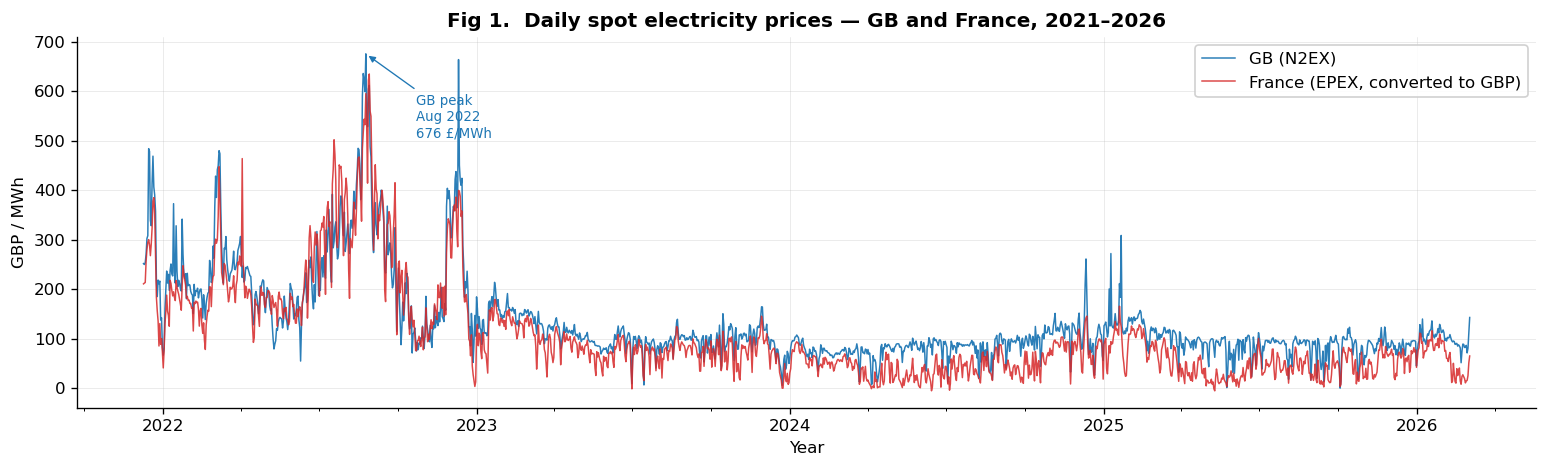

Saved: fig1_daily_prices.png


In [10]:
# ── Prepare daily series for plotting ────────────────────────────────────
daily_plot = (
    panel_complete[["gb_price_gbp", "fr_price_gbp", "spread_gbp"]]
    .resample("D").mean()
    .dropna()
)

# ── Figure 1: Daily spot prices ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(daily_plot.index, daily_plot["gb_price_gbp"],
        label="GB (N2EX)", color="#1f77b4", lw=0.9, alpha=0.95)
ax.plot(daily_plot.index, daily_plot["fr_price_gbp"],
        label="France (EPEX, converted to GBP)", color="#d62728", lw=0.9, alpha=0.85)

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.set_xlabel("Year")
ax.set_ylabel("GBP / MWh")
ax.set_title("Fig 1.  Daily spot electricity prices — GB and France, 2021–2026",
             fontweight="bold")
ax.legend(framealpha=0.9)

# annotate energy crisis peak
peak_idx = daily_plot["gb_price_gbp"].idxmax()
ax.annotate(
    f"GB peak\n{peak_idx.strftime('%b %Y')}\n{daily_plot.loc[peak_idx, 'gb_price_gbp']:.0f} £/MWh",
    xy=(peak_idx, daily_plot.loc[peak_idx, "gb_price_gbp"]),
    xytext=(30, -50), textcoords="offset points",
    fontsize=8, color="#1f77b4",
    arrowprops=dict(arrowstyle="-|>", color="#1f77b4", lw=0.8),
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig1_daily_prices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig1_daily_prices.png")

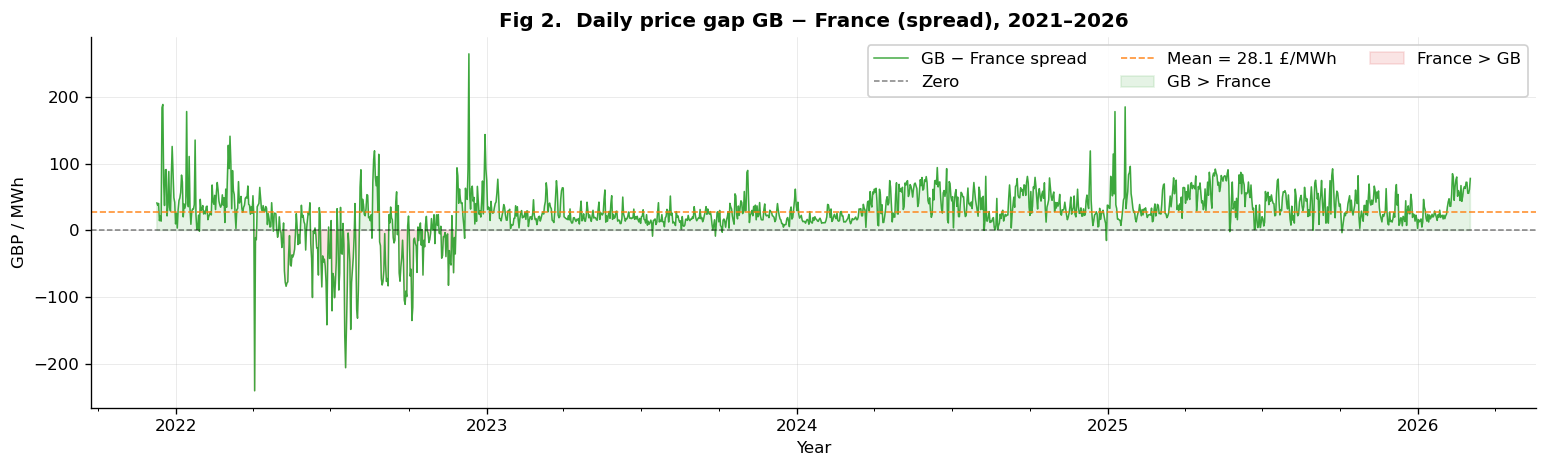

Saved: fig2_daily_spread.png


In [11]:
# ── Figure 2: Daily price gap GB − France ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4))

spread_mean = daily_plot["spread_gbp"].mean()

ax.plot(daily_plot.index, daily_plot["spread_gbp"],
        color="#2ca02c", lw=0.9, alpha=0.9, label="GB − France spread")
ax.axhline(0,           color="black", lw=0.9, ls="--", alpha=0.5, label="Zero")
ax.axhline(spread_mean, color="#ff7f0e", lw=1.0, ls="--", alpha=0.85,
           label=f"Mean = {spread_mean:.1f} £/MWh")

# shade positive spread (GB > FR) vs negative (FR > GB)
ax.fill_between(daily_plot.index, daily_plot["spread_gbp"], 0,
                where=(daily_plot["spread_gbp"] >= 0),
                alpha=0.12, color="#2ca02c", label="GB > France")
ax.fill_between(daily_plot.index, daily_plot["spread_gbp"], 0,
                where=(daily_plot["spread_gbp"] < 0),
                alpha=0.12, color="#d62728", label="France > GB")

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.set_xlabel("Year")
ax.set_ylabel("GBP / MWh")
ax.set_title("Fig 2.  Daily price gap GB − France (spread), 2021–2026",
             fontweight="bold")
ax.legend(framealpha=0.9, ncol=3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig2_daily_spread.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig2_daily_spread.png")

Non-positive prices excluded from log: GB=538, FR=1541 hours


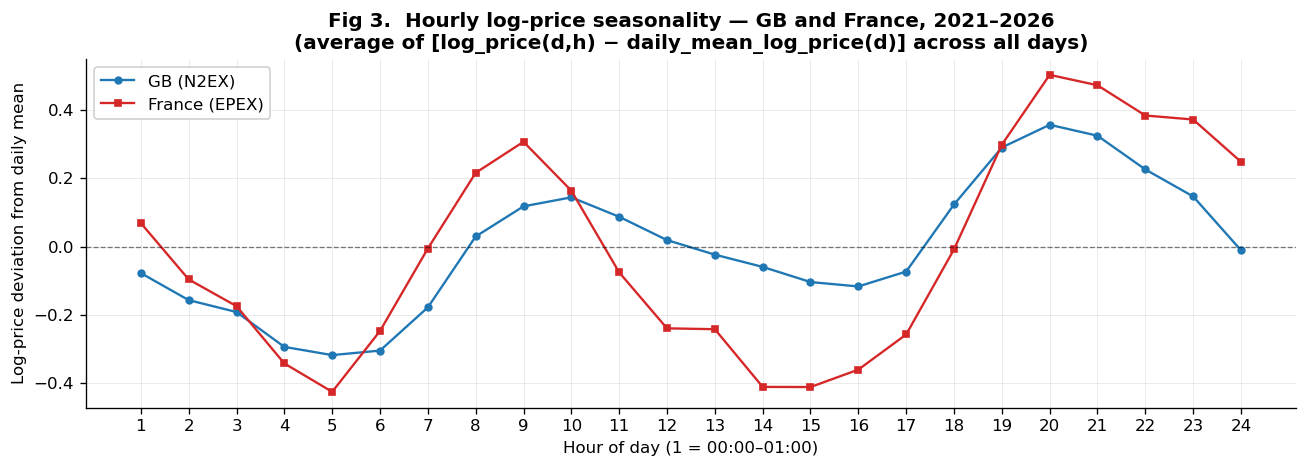


Hourly seasonality table (log-price deviation from daily mean):
      GB (N2EX)  France (EPEX)
hour                          
1       -0.0775         0.0688
2       -0.1566        -0.0960
3       -0.1915        -0.1743
4       -0.2934        -0.3419
5       -0.3175        -0.4250
6       -0.3043        -0.2470
7       -0.1780        -0.0055
8        0.0296         0.2159
9        0.1178         0.3067
10       0.1441         0.1637
11       0.0873        -0.0754
12       0.0191        -0.2392
13      -0.0235        -0.2417
14      -0.0594        -0.4106
15      -0.1037        -0.4110
16      -0.1166        -0.3600
17      -0.0730        -0.2572
18       0.1232        -0.0081
19       0.2900         0.2982
20       0.3565         0.5027
21       0.3245         0.4722
22       0.2258         0.3837
23       0.1468         0.3719
24      -0.0107         0.2481


In [12]:
# ── Figure 3: Hourly log-price seasonality (raw data, no model) ──────────
# For each hour h in {0..23} and each day d:
#   deviation(d, h) = log_price(d, h) − mean_j[log_price(d, j)]
# Seasonality(h) = mean_d[ deviation(d, h) ]
# Non-positive prices → NaN (log undefined); mask before calling np.log
# to avoid numpy divide-by-zero/invalid RuntimeWarnings.

import numpy as np

hourly_log = panel_complete[["gb_price_gbp", "fr_price_gbp"]].copy()

# Mask: compute log only where price > 0; assign NaN elsewhere
for col, log_col in [("gb_price_gbp", "log_gb"), ("fr_price_gbp", "log_fr")]:
    mask = hourly_log[col] > 0
    hourly_log[log_col] = np.nan
    hourly_log.loc[mask, log_col] = np.log(hourly_log.loc[mask, col])

n_neg_gb = (~(panel_complete["gb_price_gbp"] > 0)).sum()
n_neg_fr = (~(panel_complete["fr_price_gbp"] > 0)).sum()
print(f"Non-positive prices excluded from log: GB={n_neg_gb}, FR={n_neg_fr} hours")

# Daily mean of log price (mean across 24 hours per day)
daily_mean_log_gb = hourly_log["log_gb"].resample("D").mean()
daily_mean_log_fr = hourly_log["log_fr"].resample("D").mean()

hourly_log["day"] = hourly_log.index.normalize()
hourly_log["daily_mean_gb"] = hourly_log["day"].map(daily_mean_log_gb)
hourly_log["daily_mean_fr"] = hourly_log["day"].map(daily_mean_log_fr)

hourly_log["dev_gb"] = hourly_log["log_gb"] - hourly_log["daily_mean_gb"]
hourly_log["dev_fr"] = hourly_log["log_fr"] - hourly_log["daily_mean_fr"]

hourly_log["hour"] = hourly_log.index.hour
seasonality = (
    hourly_log.groupby("hour")[["dev_gb", "dev_fr"]]
    .mean()
    .rename(columns={"dev_gb": "GB (N2EX)", "dev_fr": "France (EPEX)"})
)
seasonality.index = seasonality.index + 1  # display as 1-24

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(seasonality.index, seasonality["GB (N2EX)"],
        marker="o", ms=4, lw=1.4, color="#1f77b4", label="GB (N2EX)")
ax.plot(seasonality.index, seasonality["France (EPEX)"],
        marker="s", ms=4, lw=1.4, color="#d62728", label="France (EPEX)")
ax.axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)

ax.set_xticks(range(1, 25))
ax.set_xlabel("Hour of day (1 = 00:00–01:00)")
ax.set_ylabel("Log-price deviation from daily mean")
ax.set_title(
    "Fig 3.  Hourly log-price seasonality — GB and France, 2021–2026\n"
    "(average of [log_price(d,h) − daily_mean_log_price(d)] across all days)",
    fontweight="bold"
)
ax.legend(framealpha=0.9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig3_hourly_seasonality.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nHourly seasonality table (log-price deviation from daily mean):")
print(seasonality.round(4).to_string())


---
## 8. Export CSVs

In [13]:
out_dir = OUTPUT_DIR
hourly_table.to_csv(out_dir / "table1_hourly_stats.csv")
daily_table.to_csv(out_dir  / "table2_daily_stats.csv")
adf_table.to_csv(out_dir    / "adf_tests.csv")
print(f"Saved to: {out_dir}")

Saved to: /Users/aadesh/Documents/IC



---
## Steps 3–7: Model Estimation and Revenue Projection

Follows Abadie & Chamorro (2021) and Cartea & González-Pedraz (2012).

| Step | Description |
|------|-------------|
| 3 | OLS: estimate deterministic f^i(t) for GB and FR log-prices separately |
| 4 | Jump detection: Cartea iterative ±3σ filter on daily residuals |
| 5 | OU estimation: AR(1) on jump-cleaned residuals + correlation ρ |
| 6 | Monte Carlo: 10,000 paths × 25 years, daily Euler scheme |
| 7 | Revenue projections: P10/P50/P90 → fan-chart + Ofgem C&F Excel model |

**Model:**  
`log P^i_t = f^i(t) + X^i_t`  
`f^i(t)` = annual + semi-annual Fourier + linear trend + weekend + 23 hourly dummies (OLS)  
`dX^i_t = −κ^i X^i_t dt + σ^i dW^i_t + J^i_t`  (OU + compound Poisson jump)  
`E[dW^GB dW^FR] = ρ dt`  (correlated Brownian motions, Cholesky)

**Revenue:** `|P^GB − P^FR| × 1000 MW × 24h × 0.95 / 10⁶` (£m/day, bidirectional flow)


In [ ]:

# ── Configuration for Steps 3–7 ──────────────────────────────────────────────
import statsmodels.api as sm

FID_YEAR     = 2028
REGIME_YEARS = 25
CAPACITY_MW  = 1_000    # IFA2 nameplate capacity (MW)
AVAILABILITY = 0.9659
N_PATHS      = 10_000
RANDOM_SEED  = 42

# Tau frozen at sample end (Mar 2026) — crisis-driven OLS trend cannot be extrapolated.
PROJ_TAU_GROWTH = 0.0   # flat nominal; set to non-zero for scenario analysis

print(f"Config: FID={FID_YEAR}  capacity={CAPACITY_MW} MW  "
      f"availability={AVAILABILITY}  N_paths={N_PATHS:,}  PROJ_TAU_GROWTH={PROJ_TAU_GROWTH}")

# ── Step 3: OLS Deterministic Component (Abadie Eq. 2) ───────────────────────
def build_features(idx: pd.DatetimeIndex, t0: pd.Timestamp,
                   include_hour_dummies: bool = True) -> pd.DataFrame:
    tau = (idx - t0).total_seconds() / (365.25 * 24 * 3600)
    df  = pd.DataFrame({
        "const":   1.0,
        "tau":     tau,
        "sin1":    np.sin(2 * np.pi * tau),
        "cos1":    np.cos(2 * np.pi * tau),
        "sin2":    np.sin(4 * np.pi * tau),
        "cos2":    np.cos(4 * np.pi * tau),
        "weekend": (idx.dayofweek >= 5).astype(float),
    }, index=idx)
    if include_hour_dummies:
        hd = pd.get_dummies(
            pd.Series(idx.hour, index=idx), prefix="H", drop_first=True
        ).astype(float)
        df = pd.concat([df, hd], axis=1)
    return df


def fit_ols_log(panel: pd.DataFrame, price_col: str, label: str) -> dict:
    s    = panel[price_col]
    pos  = s[s > 0]
    y    = np.log(pos)
    t0   = y.index[0]
    feat = build_features(y.index, t0, include_hour_dummies=True)
    res  = sm.OLS(y.values, feat).fit()
    fitted = pd.Series(res.fittedvalues, index=y.index)
    resid  = y - fitted
    excl   = (s <= 0).sum()
    params_named = pd.Series(res.params, index=feat.columns)
    print(f"  {label}: R²={res.rsquared:.4f}  N={len(y):,}  σ_resid={resid.std():.4f}"
          f"  tau_est={params_named['tau']:.4f} "
          f"({(np.exp(params_named['tau'])-1)*100:.1f}%/yr)  ({excl} excl.)")
    return {"res": res, "fitted": fitted, "resid": resid,
            "t0": t0, "cols": list(feat.columns)}


print("\nStep 3: OLS on log prices (hourly, Abadie Eq. 2):")
ols_gb = fit_ols_log(panel_complete, "gb_price_gbp", "GB")
ols_fr = fit_ols_log(panel_complete, "fr_price_gbp", "FR")

# Daily averages of hourly residuals → input to Steps 4–6
resid_gb_d = ols_gb["resid"].resample("D").mean().dropna()
resid_fr_d = ols_fr["resid"].resample("D").mean().dropna()
common_d   = resid_gb_d.index.intersection(resid_fr_d.index)
resid_gb_d = resid_gb_d.loc[common_d]
resid_fr_d = resid_fr_d.loc[common_d]

# tau at sample end → anchor for projection level
_sample_end = panel_complete.index.max()
_tau_end_gb = float((_sample_end - ols_gb["t0"]).total_seconds()) / (365.25 * 24 * 3600)
_tau_end_fr = float((_sample_end - ols_fr["t0"]).total_seconds()) / (365.25 * 24 * 3600)

print(f"\nDaily residuals: {len(common_d)} days  "
      f"({common_d[0].date()} → {common_d[-1].date()})")
print(f"tau_end: GB={_tau_end_gb:.3f} yrs  FR={_tau_end_fr:.3f} yrs  (anchoring level here)")

# 25-year projection date grid (daily)
proj_dates = pd.date_range(
    f"{FID_YEAR}-01-01", f"{FID_YEAR + REGIME_YEARS - 1}-12-31", freq="D"
)


def project_f(ols_result: dict, proj_dates: pd.DatetimeIndex,
              tau_end: float, tau_growth: float = PROJ_TAU_GROWTH) -> np.ndarray:
    """Project f(t) anchored at sample-end price level, growing at tau_growth/yr.
    Seasonal Fourier + weekend terms cycle normally; hour dummies omitted.
    """
    feat   = build_features(proj_dates, ols_result["t0"], include_hour_dummies=False)
    params = pd.Series(ols_result["res"].params, index=ols_result["cols"])
    non_h  = [c for c in ols_result["cols"] if not c.startswith("H_")]
    # Overwrite tau feature: fixed at sample-end, then grow at tau_growth/yr
    secs_from_end   = np.array((proj_dates - _sample_end).total_seconds(), dtype=float)
    yrs_from_end    = secs_from_end / (365.25 * 24 * 3600)
    feat = feat.copy()
    feat["tau"] = tau_end + tau_growth * np.clip(yrs_from_end, 0, None)
    return feat[non_h].values @ params[non_h].values


f_gb_proj = project_f(ols_gb, proj_dates, tau_end=_tau_end_gb)
f_fr_proj = project_f(ols_fr, proj_dates, tau_end=_tau_end_fr)

print(f"\nProjection: {proj_dates[0].date()} → {proj_dates[-1].date()}  "
      f"({len(proj_dates):,} days)")
print(f"  f_GB: yr1=£{np.exp(f_gb_proj[:365].mean()):.0f}/MWh  "
      f"yr25=£{np.exp(f_gb_proj[-365:].mean()):.0f}/MWh")
print(f"  f_FR: yr1=£{np.exp(f_fr_proj[:365].mean()):.0f}/MWh  "
      f"yr25=£{np.exp(f_fr_proj[-365:].mean()):.0f}/MWh")
print(f"  Implied det. spread yr1: "
      f"£{np.exp(f_gb_proj[:365].mean()) - np.exp(f_fr_proj[:365].mean()):.1f}/MWh")


In [ ]:

# ── Step 4: Jump detection (Cartea & González-Pedraz iterative filter) ────────
JUMP_THRESH = 3.0   # ±3σ band

def cartea_filter(resid: pd.Series, label: str, thresh: float = 3.0):
    """Iteratively remove observations outside ±thresh σ until convergence."""
    jumps = pd.Series(False, index=resid.index)
    for _ in range(50):
        clean = resid[~jumps]
        mu, sig = clean.mean(), clean.std()
        new_flags = (resid - mu).abs() > thresh * sig
        added = (new_flags & ~jumps).sum()
        jumps |= new_flags
        if added == 0:
            break
    j_series = resid[jumps]
    print(f"  {label}: {jumps.sum()} jumps / {len(resid)} days "
          f"  μ_clean={resid[~jumps].mean():.4f}  σ_clean={resid[~jumps].std():.4f}")
    return resid[~jumps], j_series


def _build_jump_params(jump_sizes: pd.Series, all_days: pd.DatetimeIndex) -> dict:
    """Quarterly Poisson λ + exponential β for each sign."""
    params = {}
    for sname, direction in [("pos", +1.0), ("neg", -1.0)]:
        j = jump_sizes[jump_sizes * direction > 0]
        by_q = {}
        for q in [1, 2, 3, 4]:
            n_qdays  = sum(1 for d in all_days if (d.month - 1) // 3 + 1 == q)
            n_qjumps = sum(1 for ts in j.index if (ts.month - 1) // 3 + 1 == q)
            by_q[q]  = n_qjumps / n_qdays if n_qdays > 0 else 0.0
        beta = 1.0 / j.abs().mean() if len(j) > 0 else 0.0
        params[sname] = {"lam_by_q": by_q, "beta": beta}
        lam_d = len(j) / len(all_days) if len(all_days) else 0
        print(f"    {sname}: n={len(j)}  λ={lam_d:.5f}/day  β={beta:.4f}  "
              f"Q lams={[round(by_q[q],5) for q in [1,2,3,4]]}")
    return params


print("Step 4: Jump detection on daily residuals:")
clean_gb, jump_gb = cartea_filter(resid_gb_d, "GB", JUMP_THRESH)
clean_fr, jump_fr = cartea_filter(resid_fr_d, "FR", JUMP_THRESH)

print("\nJump parameters:")
print("  GB:"); jp_gb = _build_jump_params(jump_gb, common_d)
print("  FR:"); jp_fr = _build_jump_params(jump_fr, common_d)
jump_params = {"gb": jp_gb, "fr": jp_fr}

# ── Step 5: OU estimation (AR(1) on jump-cleaned daily residuals) ─────────────
def ou_ar1(series: pd.Series, label: str) -> dict:
    y   = series.dropna().values
    X_  = sm.add_constant(y[:-1])
    res = sm.OLS(y[1:], X_).fit()
    c, phi = float(res.params[0]), float(res.params[1])
    eps    = res.resid
    kappa_yr = -np.log(max(phi, 1e-9)) * 365   # mean reversion per year
    theta    = c / (1 - phi)                     # long-run mean
    sigma_d  = float(eps.std(ddof=1))
    print(f"  {label}: φ={phi:.5f}  κ={kappa_yr:.2f}/yr  θ={theta:.4f}  σ_d={sigma_d:.5f}")
    return {"phi": phi, "c": c, "sigma_d": sigma_d, "kappa_yr": kappa_yr, "eps": eps}


# Align cleaned residuals before OU estimation
cc      = clean_gb.index.intersection(clean_fr.index)
clean_gb_a = clean_gb.loc[cc]
clean_fr_a = clean_fr.loc[cc]

print("\nStep 5: OU estimation on jump-cleaned daily residuals:")
ou_gb = ou_ar1(clean_gb_a, "GB")
ou_fr = ou_ar1(clean_fr_a, "FR")

min_n = min(len(ou_gb["eps"]), len(ou_fr["eps"]))
rho   = float(np.corrcoef(ou_gb["eps"][:min_n], ou_fr["eps"][:min_n])[0, 1])
print(f"  Correlation ρ(ε_GB, ε_FR) = {rho:.4f}")


In [ ]:

# ── Step 6: Monte Carlo Simulation ───────────────────────────────────────────
# Daily Euler scheme: X^i_{t+1} = phi*X^i_t + c + sigma*dW^i + J^i
# dW^GB, dW^FR correlated via Cholesky of [[1, rho],[rho, 1]]
# Revenue_day = |P_GB - P_FR| * capacity_MW * 24h * availability / 1e6  (£m)

rng = np.random.default_rng(RANDOM_SEED)

L = np.linalg.cholesky(np.array([[1.0, rho], [rho, 1.0]]))  # (2,2)

proj_year_arr = np.array(proj_dates.year)
proj_q_arr    = (np.array(proj_dates.month) - 1) // 3 + 1   # 1–4
n_days        = len(proj_dates)

annual_rev = np.zeros((N_PATHS, REGIME_YEARS))

BATCH = 500
print(f"Monte Carlo: {N_PATHS:,} paths × {REGIME_YEARS} yrs × {n_days:,} days  (BATCH={BATCH})")

for b0 in range(0, N_PATHS, BATCH):
    b1 = min(b0 + BATCH, N_PATHS)
    n  = b1 - b0

    # Pre-draw all correlated shocks: (n_days, 2, n)
    z  = rng.standard_normal((n_days, 2, n))
    dW = np.einsum("ij,djn->din", L, z)   # (n_days, 2, n)

    X_gb = np.zeros(n)
    X_fr = np.zeros(n)
    batch_rev = np.zeros((REGIME_YEARS, n))

    for d in range(n_days):
        q = int(proj_q_arr[d])

        # Jump components (independent Bernoulli arrival per path)
        J_gb = np.zeros(n)
        J_fr = np.zeros(n)
        for J_arr, jp in [(J_gb, jump_params["gb"]), (J_fr, jump_params["fr"])]:
            for sname, direction in [("pos", +1.0), ("neg", -1.0)]:
                lam  = jp[sname]["lam_by_q"].get(q, 0.0)
                beta = jp[sname]["beta"]
                if lam > 0 and beta > 0:
                    arrive = rng.random(n) < lam
                    if arrive.any():
                        J_arr[arrive] += direction * rng.exponential(1.0 / beta, int(arrive.sum()))

        # OU update (Euler, daily dt = 1/365)
        X_gb = ou_gb["phi"] * X_gb + ou_gb["c"] + ou_gb["sigma_d"] * dW[d, 0] + J_gb
        X_fr = ou_fr["phi"] * X_fr + ou_fr["c"] + ou_fr["sigma_d"] * dW[d, 1] + J_fr

        # Prices: FR OLS was fit on fr_price_gbp, so projection is already in GBP
        P_gb = np.exp(f_gb_proj[d] + X_gb)
        P_fr = np.exp(f_fr_proj[d] + X_fr)

        rev_d = np.abs(P_gb - P_fr) * CAPACITY_MW * 24.0 * AVAILABILITY / 1e6

        yr_idx = int(proj_year_arr[d]) - FID_YEAR
        if 0 <= yr_idx < REGIME_YEARS:
            batch_rev[yr_idx] += rev_d

    annual_rev[b0:b1] = batch_rev.T

    if (b0 // BATCH) % 4 == 0 or b1 == N_PATHS:
        print(f"  {b1}/{N_PATHS} paths  —  "
              f"Yr1 P50={np.percentile(annual_rev[:b1, 0], 50):.0f} £m")

print(f"\nSimulation complete.")
print(f"{'Yr':>3}  {'Cal':>4}  {'P10':>7}  {'P50':>7}  {'P90':>7}  £m")
for yr in [0, 4, 9, 14, 24]:
    print(f"{yr+1:>3}  {FID_YEAR+yr:>4}  "
          f"{np.percentile(annual_rev[:,yr],10):>7.1f}  "
          f"{np.percentile(annual_rev[:,yr],50):>7.1f}  "
          f"{np.percentile(annual_rev[:,yr],90):>7.1f}")


In [ ]:

# ── Step 7: Revenue projections & Excel export ────────────────────────────────
import shutil
import openpyxl

IC_DIR         = Path("/Users/aadesh/Documents/IC")
EXCEL_TEMPLATE = IC_DIR / "copy_cap_and_floor_financial_model_-_ifa2_fpa.xlsm"
INPUT_ROW      = 25    # NARt row in Ofgem Input sheet
COL_YEAR_1     = 22   # Column V (1-indexed) = Regime Year 1

p10 = np.percentile(annual_rev, 10, axis=0)
p50 = np.percentile(annual_rev, 50, axis=0)
p90 = np.percentile(annual_rev, 90, axis=0)

rev_df = pd.DataFrame({
    "cal_year":  list(range(FID_YEAR, FID_YEAR + REGIME_YEARS)),
    "regime_yr": list(range(1, REGIME_YEARS + 1)),
    "p10_gbpm":  p10.round(2),
    "p50_gbpm":  p50.round(2),
    "p90_gbpm":  p90.round(2),
    "mean_gbpm": annual_rev.mean(axis=0).round(2),
})
print("Revenue projections (£m nominal, IFA2 1 GW bidirectional):")
print(rev_df.to_string(index=False))
rev_df.to_csv(OUTPUT_DIR / "mc_revenue_projections.csv", index=False)
print(f"\nSaved: mc_revenue_projections.csv")

# Fan-chart: P10/P50/P90
fig, ax = plt.subplots(figsize=(13, 5))
yrs = rev_df["cal_year"].values
ax.fill_between(yrs, p10, p90, alpha=0.18, color="#1f77b4", label="P10–P90 range")
ax.plot(yrs, p50, color="#1f77b4", lw=2.0, label="P50 (median)")
ax.plot(yrs, p10, color="#1f77b4", lw=0.9, ls="--", alpha=0.7)
ax.plot(yrs, p90, color="#1f77b4", lw=0.9, ls="--", alpha=0.7)
ax.set_xlabel("Calendar year")
ax.set_ylabel("Annual revenue (£m nominal)")
ax.set_title(f"Fig 4.  IFA2 revenue fan chart — {N_PATHS:,} MC paths, {REGIME_YEARS}-year regime",
             fontweight="bold")
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig4_revenue_fan_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig4_revenue_fan_chart.png")

# Write P10/P50/P90 into three copies of the Ofgem Excel model
# Input!row 25, cols V–AT (columns 22–46, 25 years)
for pct_label, values in [("p10", p10), ("p50", p50), ("p90", p90)]:
    out_path = OUTPUT_DIR / f"ic_cap_floor_{pct_label}.xlsm"
    shutil.copy2(EXCEL_TEMPLATE, out_path)
    wb = openpyxl.load_workbook(out_path, keep_vba=True)
    ws = wb["Input"]
    for i, val in enumerate(values):
        ws.cell(row=INPUT_ROW, column=COL_YEAR_1 + i, value=round(float(val), 2))
    wb.save(out_path)
    wb.close()
    print(f"Written: {out_path.name}  (yr1={values[0]:.1f}, yr25={values[-1]:.1f} £m)")

print("\nOpen each .xlsm in Excel — cap/floor breach recalculates automatically.")
